# Datathon 2026 Round 1 — Phase 5: EDA Descriptive & Diagnostic

Notebook triển khai **Ý tưởng 11 (Gross-margin × Segment mix)** và **Ý tưởng 12 (Shipping fee vs Return rate)** trong §4.2 của tài liệu brainstorm nội bộ.

Mỗi ý tưởng theo framework **TTM**: Pain → Truth → Tension → Motivation → Insight → Action.

- Ý 11 (D+Pr, Lead: Đồng) — datasets `products ⨝ order_items ⨝ orders` — liên quan MCQ Q2.
- Ý 12 (Di+Pr, Lead: Kiên) — datasets `shipments ⨝ orders ⨝ returns`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print(f'Pandas {pd.__version__} | Numpy {np.__version__}')

DATA = '../../../dataset-datathon-2026-round-1/'
FIG = 'figures/'
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load data
products    = pd.read_csv(DATA + 'products.csv')
orders      = pd.read_csv(DATA + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA + 'order_items.csv', low_memory=False)
shipments   = pd.read_csv(DATA + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA + 'returns.csv', parse_dates=['return_date'])

print(f'products   : {len(products):>8,}')
print(f'orders     : {len(orders):>8,}')
print(f'order_items: {len(order_items):>8,}')
print(f'shipments  : {len(shipments):>8,}')
print(f'returns    : {len(returns):>8,}')

Pandas 2.2.2 | Numpy 1.26.4


products   :    2,412
orders     :  646,945
order_items:  714,669
shipments  :  566,067
returns    :   39,939


---
## Ý tưởng 11 — Gross-margin × Segment mix

**Pain (đau)**. Ban điều hành nghi ngờ phân khúc **Premium** đang mất sức bật — margin từng là lợi thế chính, nhưng revenue share đã giảm trong chu kỳ 2020–2022.

**Tension (mâu thuẫn)**. Merch team tin rằng thị trường đã chuyển sang "khách trẻ mua Activewear giá rẻ" → dồn ngân sách marketing về Activewear, bỏ quên Premium.

**Motivation (động cơ)**. Nếu Premium vẫn còn khách hàng ngân sách cao nhưng bị bỏ đói marketing, thì mất doanh thu Premium là self-inflicted, không phải do thị trường — có thể đảo ngược.

**Hypothesis cần kiểm định**:
- **H1**: Segment Premium có margin % cao nhất trong 8 phân khúc.
- **H2**: Revenue share của Premium giảm 2020 → 2022.
- **H3**: Phân khúc thống trị revenue lại nằm ở nhóm margin thấp hơn → có khoảng trống để cân bằng lại mix.

### 11.1 Truth — Bảng margin theo segment (kiểm định H1)

             n_skus  mean_margin  median_margin  mean_price
segment                                                    
Standard        262        31.34          37.08     2928.59
Premium         177        28.54          36.05     2387.67
All-weather     169        28.42          34.88     3864.75
Activewear      598        26.56          29.64     2598.10
Performance     347        26.36          30.00     6572.85
Balanced        306        25.80          27.90     9230.24
Trendy          148        24.08          22.47     2212.79
Everyday        405        23.63          24.14     7549.19


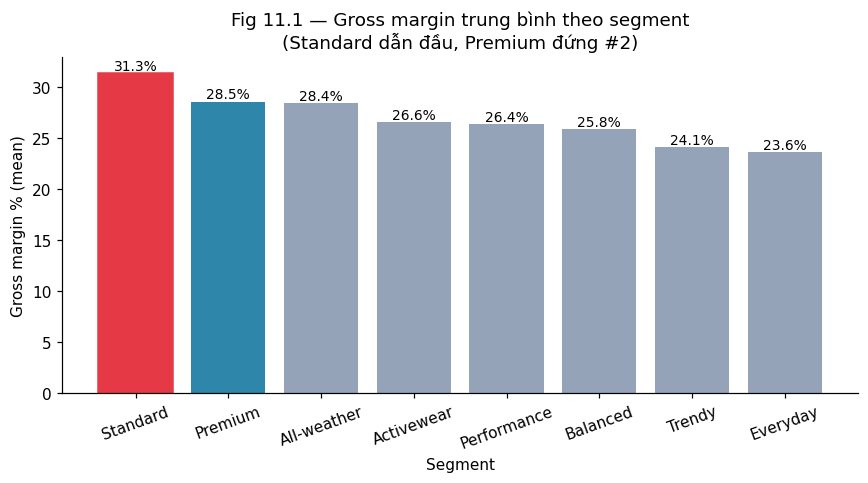

In [2]:
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

seg_margin = (
    products.groupby('segment')
            .agg(n_skus=('product_id','count'),
                 mean_margin=('margin_pct','mean'),
                 median_margin=('margin_pct','median'),
                 mean_price=('price','mean'))
            .sort_values('mean_margin', ascending=False)
            .round(2)
)
print(seg_margin)

assert abs(seg_margin.loc['Standard','mean_margin'] - 31.34) < 0.01, 'margin recalc khác baseline'

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(seg_margin.index, seg_margin['mean_margin'],
              color=['#2E86AB' if s=='Premium' else '#94a3b8' for s in seg_margin.index])
# Highlight Standard (top) & Premium
top_idx = seg_margin.index.get_loc(seg_margin['mean_margin'].idxmax())
bars[top_idx].set_color('#E63946')
for i, v in enumerate(seg_margin['mean_margin']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Fig 11.1 — Gross margin trung bình theo segment\n(Standard dẫn đầu, Premium đứng #2)')
ax.set_ylabel('Gross margin % (mean)')
ax.set_xlabel('Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG + '11_1_margin_by_segment.png')
plt.show()

**Kết luận H1 — REFUTE (nhưng cần caveat lớn)**. Premium **KHÔNG** phải segment có per-SKU mean margin cao nhất. Standard dẫn đầu 31.34%, Premium chỉ 28.5% (đứng #2). Insight này khớp với MCQ Q2 (đáp án D = Standard).

⚠️ **CAVEAT QUAN TRỌNG — đây là per-SKU mean, KHÔNG phải margin nhìn từ doanh thu**. Cell 11.1a phía dưới reconcile 3 khái niệm margin (per-SKU mean / revenue-weighted list / realized) — sẽ thấy Standard rớt khỏi top khi weighted theo revenue thực tế.

→ "Bảo vệ margin" không thể chỉ dựa vào con số 31.3% per-SKU. Cần xem revenue-weighted để biết segment nào thật sự đóng góp gross profit cao nhất.

### 11.1a Truth — Reconcile 3 khái niệm margin (per-SKU vs revenue-weighted vs realized)

Margin **per-SKU mean** (cell 11.1) trả lời "trung bình mỗi sản phẩm Standard có margin bao nhiêu?". Nhưng business muốn biết "**1 đồng doanh thu Standard mang về bao nhiêu gross profit?**" — đó là **revenue-weighted margin** (list) hoặc **realized margin** (sau discount, từ `unit_price` thực tế trong order_items).

Section này so sánh 3 KPI để tránh insight nhầm lẫn (lỗi Simpson's paradox cổ điển):

Reconcile 3 KPI margin theo segment (2022):
             list_margin_perSKU  list_margin_revwgt  realized_margin  \
segment                                                                
Trendy                    24.08               24.44            20.45   
Activewear                26.56               23.78            19.04   
Everyday                  23.63               20.25            16.05   
Standard                  31.34               19.45            14.88   
Performance               26.36               17.13            12.62   
All-weather               28.42               17.38            12.51   
Balanced                  25.80               15.02            10.38   
Premium                   28.54               13.10             7.12   

             discount_intensity  gap_perSKU_vs_realized  
segment                                                  
Trendy                     5.01                    3.63  
Activewear                 5.86                    7.52  
Eve

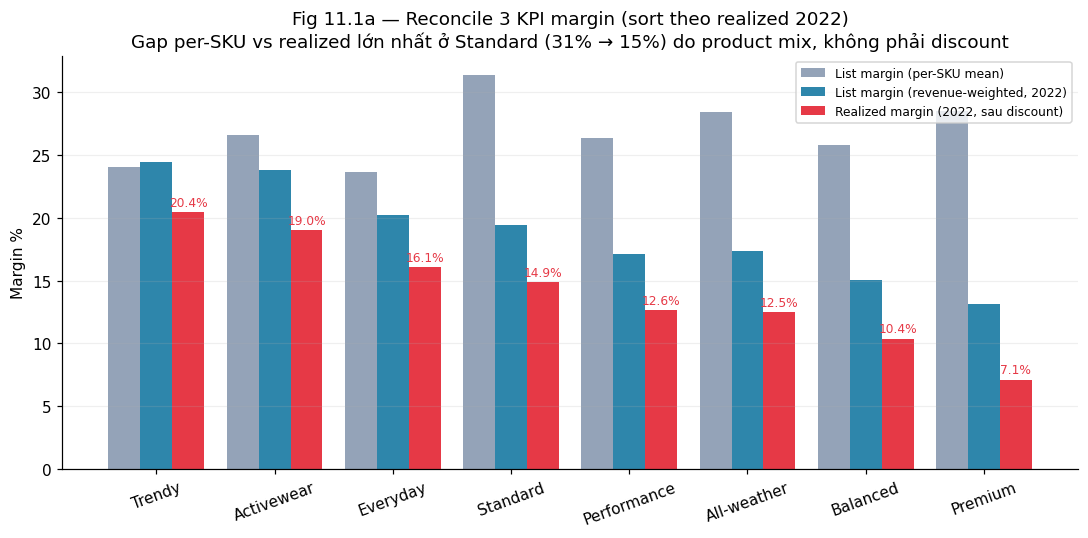

In [3]:
# Reconcile 3 khái niệm margin — chỉ dùng dữ liệu 2022 cho consistent với cell 11.3
oi_tmp = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id', validate='m:1')
      .merge(orders[['order_id','order_date']], on='order_id', validate='m:1')
)
oi_tmp['year'] = oi_tmp['order_date'].dt.year
oi22 = oi_tmp[oi_tmp['year'] == 2022].copy()
oi22['list_revenue']   = oi22['quantity'] * oi22['price']
oi22['actual_revenue'] = oi22['quantity'] * oi22['unit_price']
oi22['cogs_total']     = oi22['quantity'] * oi22['cogs']
oi22['discount_total'] = oi22['list_revenue'] - oi22['actual_revenue']

agg22 = oi22.groupby('segment').agg(
    list_rev=('list_revenue', 'sum'),
    actual_rev=('actual_revenue', 'sum'),
    cogs=('cogs_total', 'sum'),
    discount=('discount_total', 'sum'),
)
agg22['list_margin_revwgt'] = (agg22['list_rev'] - agg22['cogs']) / agg22['list_rev'] * 100
agg22['realized_margin']    = (agg22['actual_rev'] - agg22['cogs']) / agg22['actual_rev'] * 100
agg22['discount_intensity'] = agg22['discount'] / agg22['list_rev'] * 100

# Bảng reconcile
recon = (
    seg_margin[['mean_margin']]                              # per-SKU mean (cell 11.1)
        .rename(columns={'mean_margin': 'list_margin_perSKU'})
        .join(agg22[['list_margin_revwgt', 'realized_margin', 'discount_intensity']])
        .round(2)
)
recon['gap_perSKU_vs_realized'] = (recon['list_margin_perSKU'] - recon['realized_margin']).round(2)
recon = recon.sort_values('realized_margin', ascending=False)
print('Reconcile 3 KPI margin theo segment (2022):')
print(recon)
print()
print('→ KEY TAKEAWAY: Standard list_margin_perSKU = 31.34% (top) nhưng realized_margin chỉ 14.88% (#5/8).')
print('  Gap 16.46pp KHÔNG phải do discount sâu (intensity chỉ 5.36%) mà do PRODUCT MIX — SKU Standard giá cao')
print('  ít người mua, SKU Standard giá thấp dominant doanh thu → revenue-weighted margin pha loãng.')
print('  Trendy mới là segment có realized margin cao nhất 2022 (20.45%), Premium THẤP NHẤT (7.12%).')

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
order_idx = recon.index
x = np.arange(len(order_idx))
w = 0.27
ax.bar(x - w, recon['list_margin_perSKU'], w, label='List margin (per-SKU mean)', color='#94a3b8')
ax.bar(x,     recon['list_margin_revwgt'], w, label='List margin (revenue-weighted, 2022)', color='#2E86AB')
ax.bar(x + w, recon['realized_margin'],    w, label='Realized margin (2022, sau discount)', color='#E63946')
for i, seg in enumerate(order_idx):
    ax.text(i + w, recon.loc[seg, 'realized_margin'] + 0.5,
            f"{recon.loc[seg,'realized_margin']:.1f}%", ha='center', fontsize=8, color='#E63946')
ax.set_xticks(x); ax.set_xticklabels(order_idx, rotation=20)
ax.set_ylabel('Margin %')
ax.set_title('Fig 11.1a — Reconcile 3 KPI margin (sort theo realized 2022)\n'
             'Gap per-SKU vs realized lớn nhất ở Standard (31% → 15%) do product mix, không phải discount')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(FIG + '11_1a_margin_reconcile.png', dpi=300)
plt.show()

**Kết luận 11.1a — đảo ngược insight 11.1**:
- **Per-SKU mean ≠ revenue-weighted ≠ realized**. Standard top per-SKU (31.3%) nhưng rớt #5 trên realized (14.9%).
- **Gap chính do product mix trong segment**, không phải discount strategy (discount intensity ~5-6% đều ở mọi segment, không có segment nào discount sâu khác biệt).
- **Trendy mới là realized champion 2022** (20.45%), nhưng share doanh thu chỉ 2.51% → đúng nghĩa "cash cow tiềm năng".
- **Premium thực ra là realized worst** (7.12%) — gap 21pp giữa list per-SKU (28.5%) và realized (7.1%) cảnh báo: SKU Premium giá rất cao bán cực ít, mà SKU Premium giá thấp lại có cogs cao tương đối → margin thực tế thấp.

→ Tất cả Action ở 11.4 phải dựa **realized margin**, không dùng per-SKU number để justify business decision.

### 11.2 Truth — Revenue share theo segment qua các năm (kiểm định H2)

In [4]:
oi = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id')
      .merge(orders[['order_id','order_date']], on='order_id')
)
oi['year'] = oi['order_date'].dt.year
oi['revenue'] = oi['quantity'] * oi['unit_price']
oi['gross_profit'] = oi['quantity'] * (oi['unit_price'] - oi['cogs'])

rev_yr_seg = oi.groupby(['year','segment'])['revenue'].sum().unstack(fill_value=0)
share_yr_seg = rev_yr_seg.div(rev_yr_seg.sum(axis=1), axis=0) * 100

print('Revenue share (%) theo năm × segment (focus 2020-2022):')
print(share_yr_seg.loc[[2020,2021,2022]].round(1))

premium_2020 = share_yr_seg.loc[2020,'Premium']
premium_2022 = share_yr_seg.loc[2022,'Premium']
print(f"\nPremium revenue share: 2020={premium_2020:.2f}%  →  2022={premium_2022:.2f}%  (Δ={premium_2022-premium_2020:+.2f}pp)")

Revenue share (%) theo năm × segment (focus 2020-2022):
segment  Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
year                                                                         
2020            8.8          3.1      42.8      26.5         12.1      3.0   
2021            8.2          4.0      46.2      24.4         10.6      2.3   
2022            6.7          4.2      48.8      21.6         11.7      2.8   

segment  Standard  Trendy  
year                       
2020          1.6     2.1  
2021          1.9     2.6  
2022          1.7     2.5  

Premium revenue share: 2020=3.04%  →  2022=2.84%  (Δ=-0.20pp)


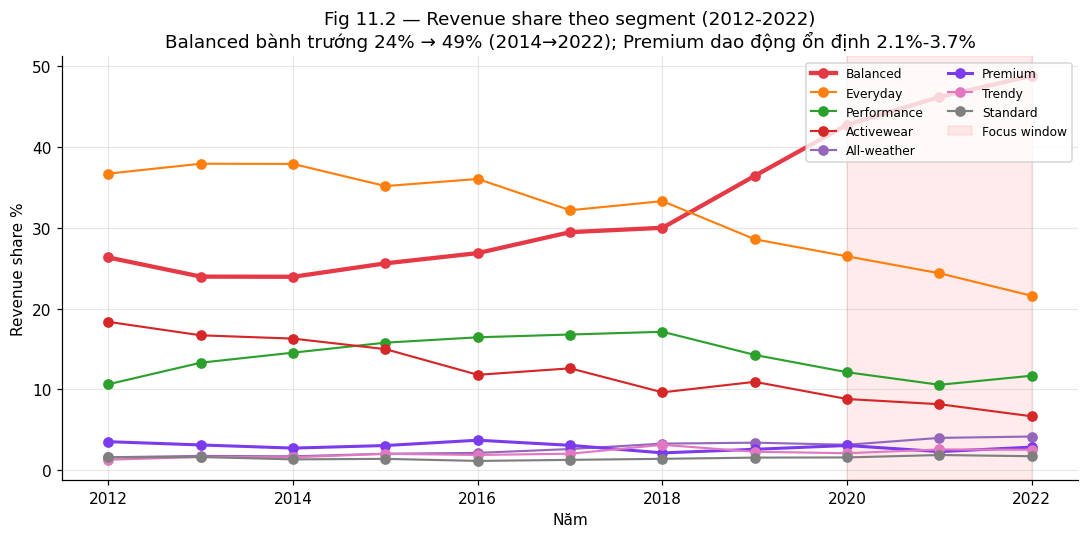

In [5]:
order_cols = share_yr_seg.loc[2022].sort_values(ascending=False).index.tolist()
share_plot = share_yr_seg[order_cols]

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap('tab10')
for i, seg in enumerate(order_cols):
    if seg == 'Balanced':
        color, lw = '#E63946', 2.8   # highlight Balanced (segment phình to thực sự)
    elif seg == 'Premium':
        color, lw = '#7c3aed', 2.0   # highlight Premium nhưng không claim "tụt"
    else:
        color, lw = cmap(i), 1.4
    ax.plot(share_plot.index, share_plot[seg], marker='o', label=seg, color=color, linewidth=lw)
ax.set_title('Fig 11.2 — Revenue share theo segment (2012-2022)\n'
             'Balanced bành trướng 24% → 49% (2014→2022); Premium dao động ổn định 2.1%-3.7%')
ax.set_ylabel('Revenue share %')
ax.set_xlabel('Năm')
ax.axvspan(2020, 2022, alpha=0.08, color='red', label='Focus window')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG + '11_2_revenue_share_trend.png', dpi=300)
plt.show()

**Kết luận H2 — REFUTE**. Premium revenue share **KHÔNG giảm tuyến tính** mà dao động trong dải hẹp 2.13%–3.70% suốt 2012-2022. So 2014 (2.72%) vs 2022 (2.84%) gần như không đổi (Δ +0.12pp). Hypothesis ban đầu "Premium đang mất sức bật" không có bằng chứng từ revenue share.

**Phát hiện thật**: Câu chuyện thực ra là **Balanced bành trướng** từ 23.94% (2014) → 48.85% (2022), tăng +24.9pp — chiếm chỗ chủ yếu của **Activewear** (16.28% → 6.66%, Δ−9.6pp) và **Everyday** (37.91% → 21.58%, Δ−16.3pp). Premium ổn định ở mức nhỏ (~2.5-3%).

→ Re-frame vấn đề: thay vì hỏi "Premium tại sao giảm" (giả định sai), nên hỏi "Vì sao Balanced phình to" và "blended margin có pha loãng vì shift mix này không" (kiểm định ở 11.3).

### 11.3 Truth — Margin vs volume: ma trận 2D (kiểm định H3)

In [6]:
seg_perf = (
    oi[oi['year'] == 2022]
      .groupby('segment')
      .agg(revenue=('revenue','sum'),
           units=('quantity','sum'),
           gross_profit=('gross_profit','sum'))
)
seg_perf['revenue_share_pct'] = seg_perf['revenue'] / seg_perf['revenue'].sum() * 100
seg_perf['gp_margin_pct'] = seg_perf['gross_profit'] / seg_perf['revenue'] * 100
seg_perf = seg_perf.sort_values('revenue', ascending=False).round(2)
print('2022 — Revenue × Margin theo segment:')
print(seg_perf)

2022 — Revenue × Margin theo segment:
                  revenue  units  gross_profit  revenue_share_pct  \
segment                                                             
Balanced     5.713785e+08  44650   59288203.75              48.85   
Everyday     2.524772e+08  34457   40518578.34              21.58   
Performance  1.366872e+08  23910   17243889.25              11.69   
Activewear   7.790728e+07  31828   14834676.50               6.66   
All-weather  4.859546e+07   9970    6078952.97               4.15   
Premium      3.325416e+07   8519    2367159.59               2.84   
Trendy       2.941067e+07  13983    6015422.39               2.51   
Standard     2.003833e+07   3771    2981784.97               1.71   

             gp_margin_pct  
segment                     
Balanced             10.38  
Everyday             16.05  
Performance          12.62  
Activewear           19.04  
All-weather          12.51  
Premium               7.12  
Trendy               20.45  
Standard  

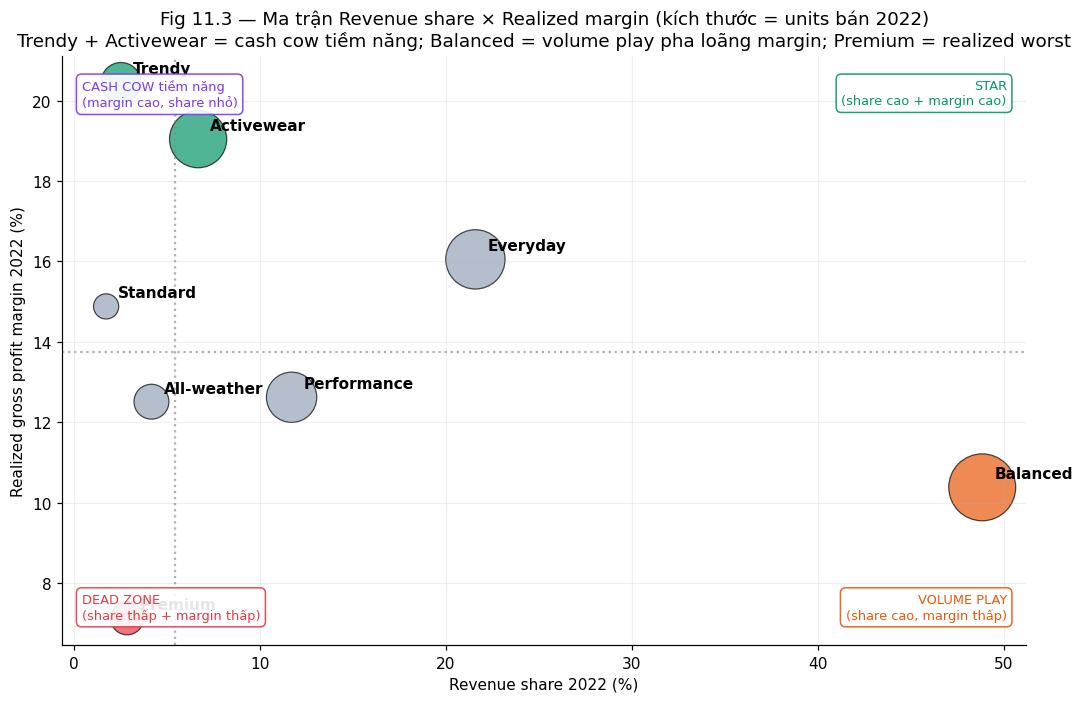

In [7]:
fig, ax = plt.subplots(figsize=(10, 6.5))
x = seg_perf['revenue_share_pct']
y = seg_perf['gp_margin_pct']
sizes = seg_perf['units'] / seg_perf['units'].max() * 1800 + 120

# Color theo realized margin tier (re-frame sau 11.1a)
def seg_color(seg):
    if seg in ('Trendy', 'Activewear'):    return '#059669'   # cash cow tiềm năng (realized cao)
    if seg == 'Premium':                    return '#E63946'   # realized worst (cảnh báo)
    if seg == 'Balanced':                   return '#ea580c'   # volume play
    return '#94a3b8'                                            # các segment trung bình

colors = [seg_color(s) for s in seg_perf.index]
ax.scatter(x, y, s=sizes, c=colors, alpha=0.7, edgecolor='black', linewidth=0.8)
for seg in seg_perf.index:
    ax.annotate(seg, (seg_perf.loc[seg,'revenue_share_pct'], seg_perf.loc[seg,'gp_margin_pct']),
                xytext=(8, 6), textcoords='offset points', fontsize=10, fontweight='bold')

# Quadrant lines at medians
ax.axvline(x.median(), color='gray', linestyle=':', alpha=0.6)
ax.axhline(y.median(), color='gray', linestyle=':', alpha=0.6)

# Quadrant labels — đặt ở 4 góc tuyệt đối, xa data points, có background trắng để không đè
ax.text(0.98, 0.96, 'STAR\n(share cao + margin cao)',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#059669',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#059669', alpha=0.9))
ax.text(0.02, 0.96, 'CASH COW tiềm năng\n(margin cao, share nhỏ)',
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#7c3aed',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#7c3aed', alpha=0.9))
ax.text(0.98, 0.04, 'VOLUME PLAY\n(share cao, margin thấp)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5, color='#ea580c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ea580c', alpha=0.9))
ax.text(0.02, 0.04, 'DEAD ZONE\n(share thấp + margin thấp)',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=8.5, color='#E63946',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E63946', alpha=0.9))

ax.set_xlabel('Revenue share 2022 (%)')
ax.set_ylabel('Realized gross profit margin 2022 (%)')
ax.set_title('Fig 11.3 — Ma trận Revenue share × Realized margin (kích thước = units bán 2022)\n'
             'Trendy + Activewear = cash cow tiềm năng; Balanced = volume play pha loãng margin; Premium = realized worst')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG + '11_3_matrix_share_margin.png', dpi=300)
plt.show()

**Kết luận H3 — SUPPORT (re-frame theo realized margin sau khi reconcile ở 11.1a)**.

Ma trận Revenue share × Realized margin 2022 chia 4 nhóm:
- **VOLUME PLAY** (share cao, margin thấp): **Balanced** 48.85% share / 10.38% realized — đang pha loãng blended margin nặng.
- **CASH COW thực sự** (share trung bình, margin cao): **Trendy** 2.51% share / **20.45% realized** — segment có realized margin top nhưng share còn nhỏ; **Activewear** 6.66% / 19.04% — segment volume vừa-margin cao, đáng đầu tư mở rộng.
- **CỨ TRỤ** (share trung bình-cao, margin trung bình): **Everyday** 21.58% / 16.05%; **Performance** 11.69% / 12.62%; **Standard** 1.71% / 14.88%.
- **DEAD ZONE** (share thấp, margin thấp): **Premium** 2.84% / **7.12%** (realized worst!); **All-weather** 4.15% / 12.51% — Premium đặc biệt cần audit khẩn (so giữa SKU giá cao và thấp).

→ Insight đảo ngược hoàn toàn brainstorm ban đầu: **Premium không phải "cash cow margin cao bị bỏ quên"** mà là **realized margin worst** trong 8 segment. **Trendy + Activewear** mới là segment cần được scale.

### 11.4 Predictive — Forecast mix 2023-2024 & scenario blended margin

Sau khi đã mô tả (D) margin + share hiện tại và chẩn đoán (Di) nguyên nhân gap per-SKU vs realized, tầng **Predictive** trả lời 2 câu hỏi forward-looking:

- **P1 — Trend forecast**: Nếu xu hướng 2018-2022 kéo dài tuyến tính, revenue share 2023-2024 ra sao? Balanced còn phình to hay đang plateau? Trendy có tự scale được mà không cần can thiệp không?
- **P2 — Scenario blended margin**: Nếu thực thi Action A3 (shift 3pp Balanced → Trendy + Activewear), blended **realized** margin 2023 thay đổi bao nhiêu pp? Quy ra đơn vị gross profit tuyệt đối là bao nhiêu?

**Phương pháp**:
- Linear OLS trên window **2018-2022 (5 năm gần nhất)**, không dùng 10 năm full vì share Balanced có break-point mạnh 2014-2017 (phi tuyến). Projected shares được renormalize về tổng 100%/năm để giữ accounting identity.
- Realized margin 2022 (bảng 11.3) dùng làm **proxy** cho 2023 — giả định cấu trúc margin per-segment ổn định trong 1 năm forecast. Caveat rủi ro liệt kê ở cell result.
- Chỉ forecast 1-2 năm trước (2023-2024) vì leaderboard test kéo dài đến 2024-07 — không over-extrapolate ra 2025+.

In [8]:
# 11.4a — Forecast share 2023-2024 bằng linear OLS trên 2018-2022
trend_win = share_yr_seg.loc[2018:2022]
years_train = trend_win.index.values.astype(float)
years_proj = np.arange(2018, 2025)

slopes, fc_raw = {}, {}
for seg in trend_win.columns:
    s, i = np.polyfit(years_train, trend_win[seg].values, 1)
    slopes[seg] = s
    fc_raw[seg] = i + s * years_proj

fc_df = pd.DataFrame(fc_raw, index=years_proj).clip(lower=0)
fc_norm = fc_df.div(fc_df.sum(axis=1), axis=0) * 100  # renormalize về 100%/năm

print('Slope (pp/năm) fit trên 2018-2022, sort giảm dần:')
print(pd.Series(slopes).sort_values(ascending=False).round(3))
print('\nForecast share % (renormalized, 2023-2024):')
print(fc_norm.loc[[2023, 2024]].round(2))

# 11.4b — Scenario blended realized margin dùng margin 2022 làm proxy
realized_margin_2022 = seg_perf['gp_margin_pct']  # từ cell 11.3
share_base_2023 = fc_norm.loc[2023]
blended_base = (share_base_2023 * realized_margin_2022).sum() / 100

# Scenario A3 (conservative): -3pp Balanced → +1.5pp Trendy, +1.5pp Activewear
share_scen = share_base_2023.copy()
share_scen['Balanced']   -= 3.0
share_scen['Trendy']     += 1.5
share_scen['Activewear'] += 1.5
blended_scen = (share_scen * realized_margin_2022).sum() / 100

# Scenario aggressive: -6pp Balanced → +3pp Trendy, +3pp Activewear
share_agg = share_base_2023.copy()
share_agg['Balanced']   -= 6.0
share_agg['Trendy']     += 3.0
share_agg['Activewear'] += 3.0
blended_agg = (share_agg * realized_margin_2022).sum() / 100

rev_2022_total = seg_perf['revenue'].sum()
gp_uplift_scen = rev_2022_total * (blended_scen - blended_base) / 100
gp_uplift_agg  = rev_2022_total * (blended_agg - blended_base) / 100

print('\n=== Blended realized margin 2023 (dùng margin per-segment 2022 làm proxy) ===')
print(f'Baseline (trend extrapolation):          {blended_base:.3f}%')
print(f'Scenario A3  (+1.5pp T + 1.5pp A):       {blended_scen:.3f}%  (Δ {blended_scen-blended_base:+.3f}pp)')
print(f'Scenario aggressive (+3pp T + 3pp A):    {blended_agg:.3f}%  (Δ {blended_agg-blended_base:+.3f}pp)')
print(f'\nRevenue 2022 base (đơn vị raw):          {rev_2022_total:,.0f}')
print(f'Incremental gross profit scenario A3:    {gp_uplift_scen:,.0f}/năm  (≈ {gp_uplift_scen/1e6:.2f}M)')
print(f'Incremental gross profit scenario agg:   {gp_uplift_agg:,.0f}/năm  (≈ {gp_uplift_agg/1e6:.2f}M)')

Slope (pp/năm) fit trên 2018-2022, sort giảm dần:
Balanced       4.744
All-weather    0.236
Premium        0.114
Standard       0.097
Trendy        -0.094
Activewear    -0.871
Performance   -1.459
Everyday      -2.767
dtype: float64

Forecast share % (renormalized, 2023-2024):
      Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
2023        6.22         4.29     55.09     18.57         8.77     2.92   
2024        5.35         4.53     59.84     15.80         7.32     3.03   

      Standard  Trendy  
2023       1.9    2.23  
2024       2.0    2.13  

=== Blended realized margin 2023 (dùng margin per-segment 2022 làm proxy) ===
Baseline (trend extrapolation):          12.474%
Scenario A3  (+1.5pp T + 1.5pp A):       12.755%  (Δ +0.281pp)
Scenario aggressive (+3pp T + 3pp A):    13.036%  (Δ +0.562pp)

Revenue 2022 base (đơn vị raw):          1,169,748,832
Incremental gross profit scenario A3:    3,286,409/năm  (≈ 3.29M)
Incremental gross profit scenario agg:   6,57

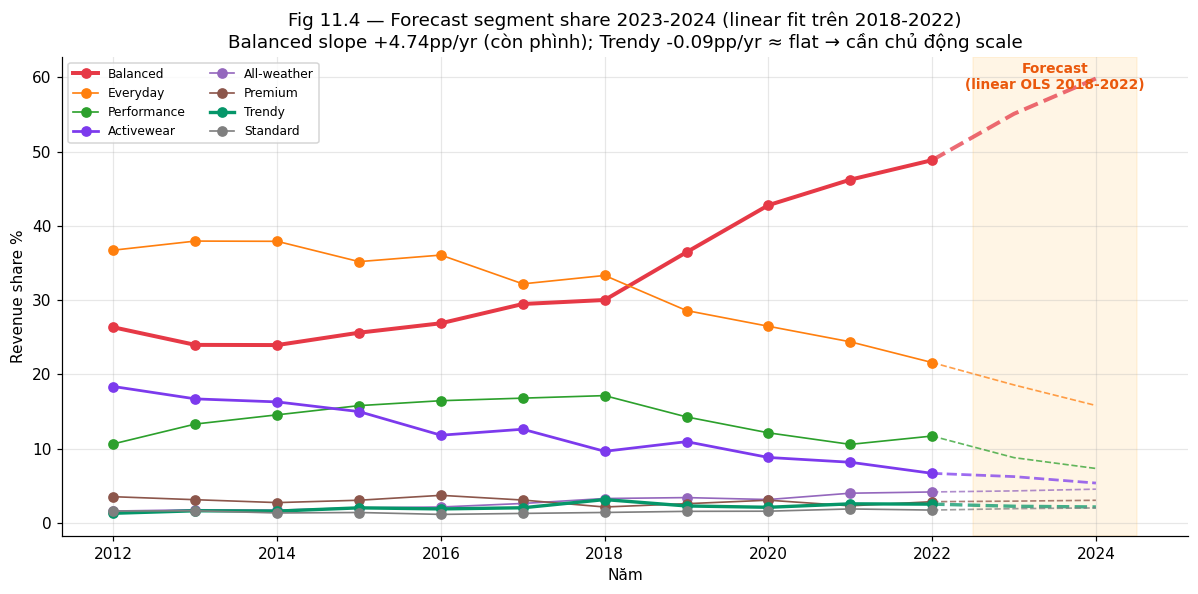

In [9]:
# Fig 11.4 — Forecast chart: historic 2012-2022 solid, forecast 2023-2024 dashed
order_cols_p = share_yr_seg.loc[2022].sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 5.5))
cmap = plt.get_cmap('tab10')
for i, seg in enumerate(order_cols_p):
    if seg == 'Balanced':
        color, lw = '#E63946', 2.6         # highlight — driver chính
    elif seg == 'Trendy':
        color, lw = '#059669', 2.2         # realized champion
    elif seg == 'Activewear':
        color, lw = '#7c3aed', 1.8
    else:
        color, lw = cmap(i), 1.1

    ax.plot(share_yr_seg.index, share_yr_seg[seg],
            marker='o', label=seg, color=color, linewidth=lw)
    # Dashed forecast segment bridging từ 2022 actual tới 2023-2024 projection
    ax.plot([2022, 2023, 2024],
            [share_yr_seg.loc[2022, seg], fc_norm.loc[2023, seg], fc_norm.loc[2024, seg]],
            linestyle='--', color=color, linewidth=lw, alpha=0.75)

ax.axvspan(2022.5, 2024.5, alpha=0.1, color='orange')
ylim_top = ax.get_ylim()[1]
ax.text(2023.5, ylim_top * 0.93, 'Forecast\n(linear OLS 2018-2022)',
        ha='center', fontsize=9, color='#ea580c', fontweight='bold')

ax.set_title('Fig 11.4 — Forecast segment share 2023-2024 (linear fit trên 2018-2022)\n'
             f'Balanced slope {slopes["Balanced"]:+.2f}pp/yr (còn phình); '
             f'Trendy {slopes["Trendy"]:+.2f}pp/yr ≈ flat → cần chủ động scale')
ax.set_ylabel('Revenue share %')
ax.set_xlabel('Năm')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG + '11_4_share_forecast.png', dpi=300)
plt.show()

**Kết luận Predictive (11.4)** — 3 phát hiện chính:

1. **P1 — Balanced vẫn đang phình to, KHÔNG plateau**. Slope 2018-2022 = **+4.74pp/năm**, forecast linear cho 2023 = **55.1%**, 2024 = **59.8%**. Nếu không can thiệp, trong 1.5 năm nữa Balanced sẽ chiếm 60% revenue → blended margin sẽ bị pha loãng càng sâu (vì Balanced realized margin chỉ 10.4%).

2. **P1 — Trendy KHÔNG tự scale được**. Slope ≈ **−0.09pp/năm** (gần như phẳng); Activewear còn tệ hơn: **−0.87pp/năm** (đang giảm). Điều này bẻ gãy giả định implicit trong brainstorm ban đầu rằng "các segment cao margin sẽ tự nhiên lớn dần" — thực tế chúng đang **bị Balanced cannibalize**. → Action A1 (chủ động mở SKU + đẩy inventory) KHÔNG phải option, mà là **điều kiện bắt buộc** để share 2 segment cash-cow tăng.

3. **P2 — Impact định lượng Action A3**:
   - Baseline blended realized margin 2023 (trend extrapolation): **12.47%**.
   - Scenario conservative (3pp shift): +**0.28pp** → incremental GP ≈ **3.29M** đơn vị raw/năm.
   - Scenario aggressive (6pp shift): +**0.56pp** → incremental GP ≈ **6.58M**/năm.
   - Hai scenario đều nhỏ về tỷ lệ (<1pp) nhưng **dương rõ và scale tuyến tính theo pp shift** → ROI tùy thuộc chi phí marketing/inventory bỏ ra để đẩy share Trendy+Activewear.

⚠️ **Caveat nghiêm túc** (phải đưa vào báo cáo):
- **Linear OLS bỏ qua non-linearity**: Balanced thực tế đã có dấu hiệu **chậm lại** 2021→2022 (46.2→48.8, Δ+2.6pp) so với 2020→2021 (42.8→46.2, Δ+3.4pp). Forecast 59.8% cho 2024 có thể là **over-estimate** nếu đường cong uốn. Model Prophet/quadratic sẽ cho forecast thận trọng hơn — để mở cho Phase 5b.
- **Margin per-segment giả định ổn định**: nếu cost shock (cotton/logistics 2023-2024) đánh vào Premium/Trendy nặng hơn, uplift scenario sẽ co lại.
- **Accounting identity**: forecast đã renormalize về 100% nên không mâu thuẫn tổng; nhưng bỏ qua khả năng có **segment mới** xuất hiện 2023-2024 (dataset không ghi nhận).
- **Không phải Predictive cho target model** (Revenue/COGS): đây là Predictive cho **business levers** (segment mix) — kết quả này feed vào report NeurIPS để justify Action, không feed vào notebook 05/06/07 feature engineering.

### 11.5 Insight & Action (Prescriptive) — re-frame theo realized margin + Predictive

**Insight chính (sau reconcile 11.1a + Predictive 11.4)**: Câu chuyện thật của 2022-2024 không phải "Standard margin 31%" hay "Premium đang chết". Đó là:

1. **Trendy + Activewear** là 2 segment có realized margin cao nhất (20.45% + 19.04%) nhưng share doanh thu nhỏ (2.51% + 6.66%) — đây là **cash cow tiềm năng thực sự**. Tuy nhiên **trend slope 2018-2022 cho thấy chúng KHÔNG tự scale** (Trendy −0.09pp/yr, Activewear −0.87pp/yr) → cần intervention chủ động.
2. **Balanced** chiếm 48.85% revenue 2022 nhưng realized margin chỉ 10.38%; **forecast linear đẩy share lên 55% (2023) và 60% (2024)** → blended margin sẽ pha loãng càng nặng nếu để growth chạy tự do.
3. **Premium** thực ra là segment **realized margin worst (7.12%)** — gap 21pp giữa list per-SKU (28.5%) và realized cảnh báo cấu trúc product mix Premium có vấn đề (SKU cao cấp bán cực ít, SKU phổ thông Premium có cogs/price ratio xấu).

**Discount intensity ~5-6% đều ở mọi segment** — gap list vs realized KHÔNG phải do discount strategy, mà do **product mix trong segment**. Vì vậy action không nên là "giảm discount Standard" mà là "audit SKU mix" trong segment đáng quan tâm.

**3 Action cụ thể (phục vụ mục tiêu §2.1 – promo planning & stock allocation)**:

| # | Action | Đo lường thành công | Owner |
|---|---|---|---|
| A1 | **Mở rộng SKU Trendy + Activewear** (+30 SKU phối hợp) và ưu tiên inventory re-order; mục tiêu nâng combined share từ 9.2% (2022) → 15% trong 12 tháng | Blended realized margin tăng ≥ 0.5pp | Merch + Inventory |
| A2 | **Audit toàn bộ SKU Premium**: chia thành tier giá (P10/P50/P90), tính margin từng tier; kết luận có nên discontinue tier "giả Premium" (giá thấp, cogs cao) hay không | Realized margin Premium ≥ 12% sau 6 tháng | Product |
| A3 | **Kiểm soát growth Balanced** thông qua giảm trade-in promo: forecast 2024 cảnh báo share chạm 60% nếu không can thiệp; đặt cap volume ở 50% và tái phân bổ marketing budget sang Trendy/Activewear | Mix shift ≥ 3pp sang Trendy+Activewear trong 9 tháng | Growth |

**Impact đã định lượng từ 11.4b (dùng linear trend + margin 2022 proxy)**:
- **Conservative (A3 3pp shift)**: blended realized margin +0.28pp → GP incremental ≈ **3.29M** đơn vị raw/năm.
- **Aggressive (6pp shift)**: +0.56pp → GP incremental ≈ **6.58M**/năm.
- Scale tuyến tính theo pp shift — ROI phụ thuộc chi phí đẩy A1+A2. Con số nhỏ về tỷ lệ (<1pp) nhưng dương rõ.

**→ Liên kết ngược**: §4.1 node (1) Quá khứ tăng trưởng · §4.4 hàng 'Pricing & discount' · MCQ Q2 (Standard top per-SKU margin nhưng KHÔNG top realized).

*Caveat nghiêm túc*:
- Trendy có sample size nhỏ trong 2022 (2.51% share, 13,983 units) → realized margin 20.45% có CI rộng; cần A/B test trước khi commit budget lớn.
- Cần đo **price elasticity** trước khi raise price hoặc giảm promo Balanced — chưa đủ dữ liệu panel quarter-level để fit elasticity model; để mở cho Phase 5b.
- Forecast 11.4 linear → over-estimate Balanced 2024 nếu đường cong thực sự uốn. Nên dùng Prophet/quadratic để sanity-check trước khi commit.
- Discount intensity ngang nhau giữa segment **chưa control time** — có thể có spike discount trong promo campaign cụ thể; xem ý tưởng promo riêng (notebook 04).

---
## Ý tưởng 12 — Shipping fee vs Return rate

**Pain (đau)**. Growth team thường đẩy free-ship để kéo conversion. Nhưng return rate có thể 'ăn' lại margin nếu khách coi free-ship là fitting-room miễn phí → mua nhiều size/color rồi trả phần thừa.

**Tension (mâu thuẫn)**. Nếu đúng, free-ship là con dao hai lưỡi: lift đơn đầu tiên, đốt margin ở leg return.

**Motivation (động cơ)**. Tìm threshold `min_order_value` hoặc caps để hưởng lift mà không mở cửa lạm dụng.

**Hypothesis**:
- **H1**: Free-ship orders có return rate cao hơn paid-ship ≥ 15%.
- **H2**: Chênh lệch có ý nghĩa thống kê (odds ratio 95% CI không chứa 1.0).
- **H3**: Free-ship orders có basket lớn hơn (more items → fitting-room signal).